# 🏠 House Price Prediction — Machine Learning Regression Project

**Dataset:** King County, WA House Sales (Kaggle)  
**Target Variable:** `price` — house sale price in USD  
**Models:** Ridge Regression · Random Forest Regressor  
**Author:** Machine Learning Demo Project

---

## Project Pipeline
1. Import Libraries
2. Load & Inspect the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Train / Test Split
7. Model Training — Ridge Regression
8. Model Training — Random Forest Regressor
9. Model Evaluation & Comparison
10. Feature Importance
11. Conclusion

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded. Versions:')
print(f'  pandas   {pd.__version__}')
print(f'  numpy    {np.__version__}')
import sklearn; print(f'  sklearn  {sklearn.__version__}')
import matplotlib; print(f'  matplotlib {matplotlib.__version__}')

Libraries loaded. Versions:
  pandas   2.2.2
  numpy    2.0.2
  sklearn  1.6.1
  matplotlib 3.9.4


---
## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_csv('data.csv')

print(f'Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head(8)

Shape   : 4,600 rows × 18 columns
Memory  : 1993.6 KB


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA


In [3]:
# Column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
# Statistical summary of numeric columns
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.99,563834.70,0.0,322875.00,460943.46,654962.50,26590000.0
bedrooms,4600.0,3.40,0.91,0.0,3.00,3.00,4.00,9.0
bathrooms,4600.0,2.16,0.78,0.0,1.75,2.25,2.50,8.0
sqft_living,4600.0,2139.35,963.21,370.0,1460.00,1980.00,2620.00,13540.0
sqft_lot,4600.0,14852.52,35884.44,638.0,5000.75,7683.00,11001.25,1074218.0
floors,4600.0,1.51,0.54,1.0,1.00,1.50,2.00,3.5
waterfront,4600.0,0.01,0.08,0.0,0.00,0.00,0.00,1.0
view,4600.0,0.24,0.78,0.0,0.00,0.00,0.00,4.0
condition,4600.0,3.45,0.68,1.0,3.00,3.00,4.00,5.0
sqft_above,4600.0,1827.27,862.17,370.0,1190.00,1590.00,2300.00,9410.0


In [5]:
# Missing value check
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.any() else '  None — dataset is complete!')
print()

# Price anomalies
print(f'Rows with price == 0          : {(df["price"] == 0).sum()}')
print(f'Rows with price <= $50,000    : {(df["price"] <= 50000).sum()}')
print(f'Rows with bedrooms > 10       : {(df["bedrooms"] > 10).sum()}')
print(f'99.5th percentile price       : ${df["price"].quantile(0.995):,.0f}')
print(f'Max price                     : ${df["price"].max():,.0f}')

Missing values:
  None — dataset is complete!

Rows with price == 0          : 49
Rows with price <= $50,000    : 50
Rows with bedrooms > 10       : 0
99.5th percentile price       : $2,400,000
Max price                     : $26,590,000


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Price Distribution

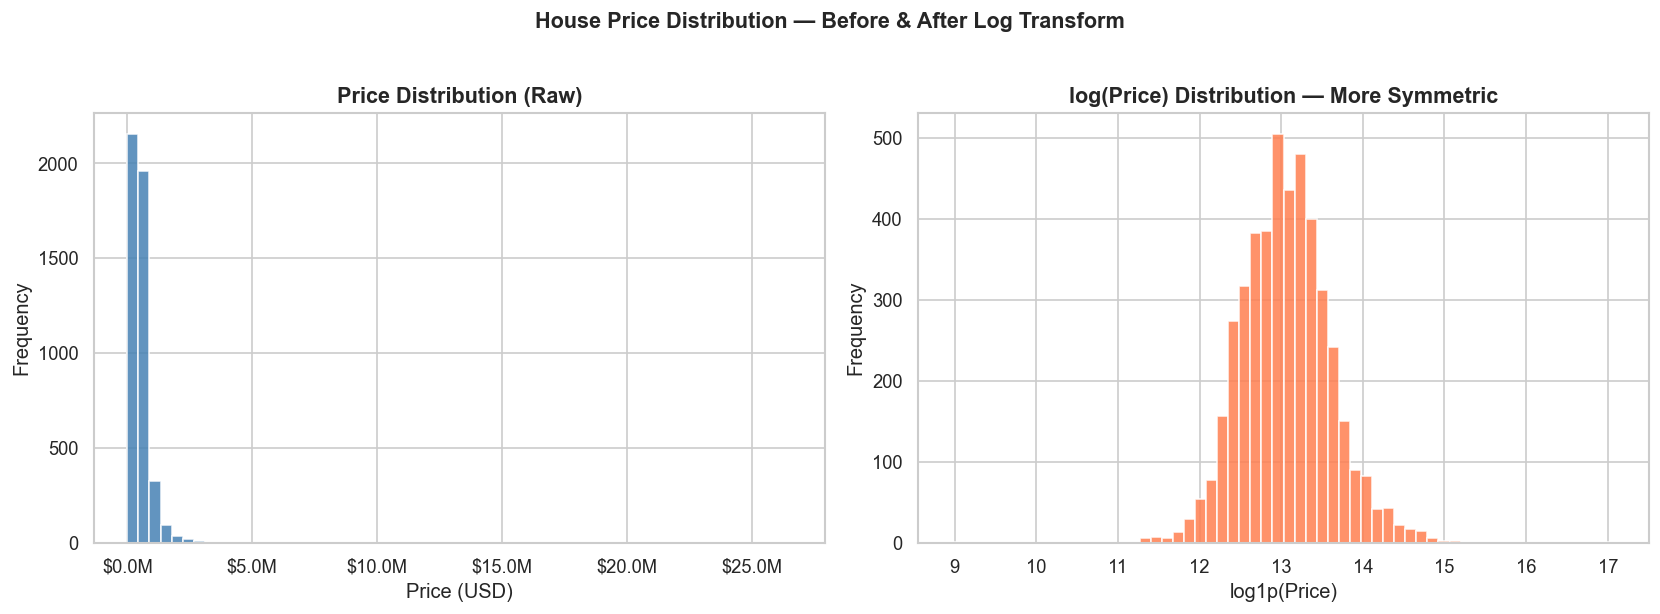

Mean price   : $   551,963
Median price : $   460,943
Std deviation: $   563,835
Skewness     : 24.79  (right-skewed — extreme outliers present)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].hist(np.log1p(df[df['price'] > 0]['price']), bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('log(Price) Distribution — More Symmetric', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('House Price Distribution — Before & After Log Transform',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()

print(f'Mean price   : ${df["price"].mean():>10,.0f}')
print(f'Median price : ${df["price"].median():>10,.0f}')
print(f'Std deviation: ${df["price"].std():>10,.0f}')
print(f'Skewness     : {df["price"].skew():.2f}  (right-skewed — extreme outliers present)')

### 3.2 Feature Distributions

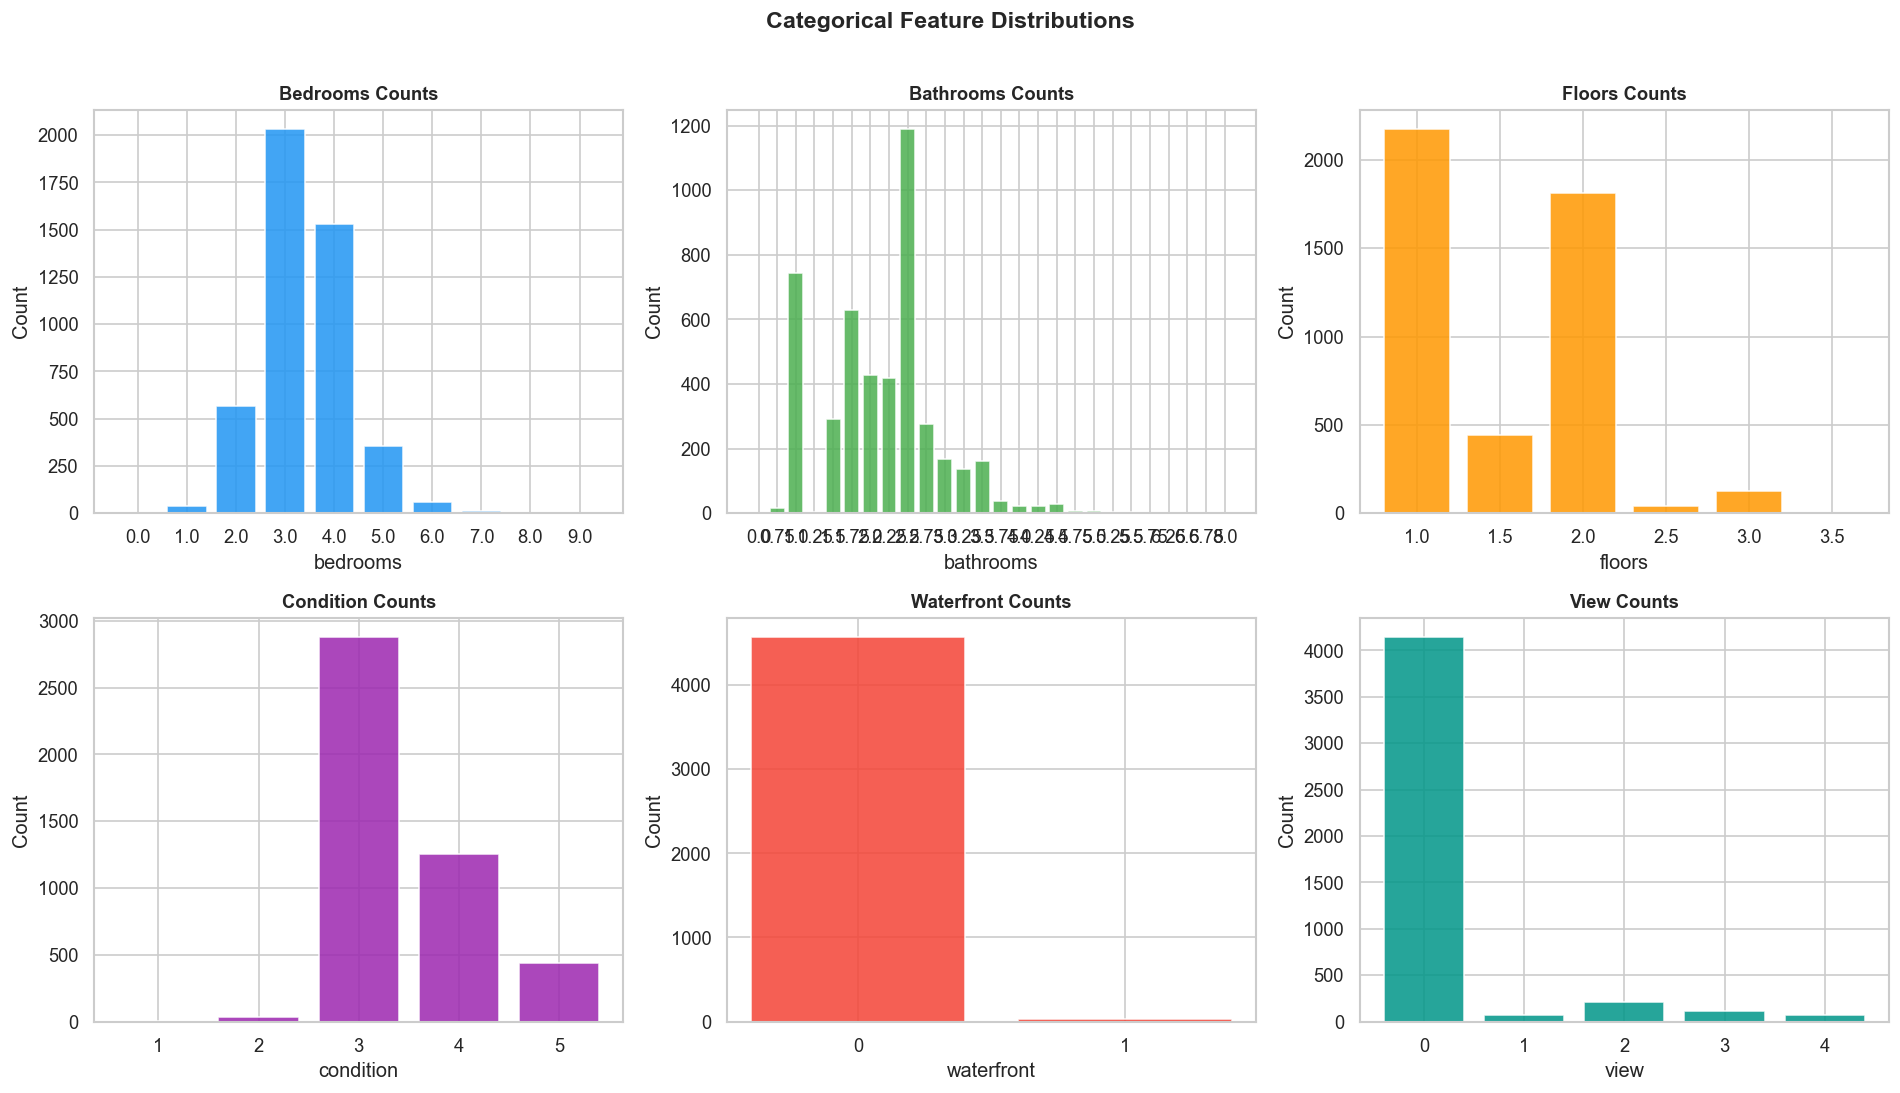

In [7]:
cat_features = ['bedrooms', 'bathrooms', 'floors', 'condition', 'waterfront', 'view']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']

for i, col in enumerate(cat_features):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col.replace("_"," ").title()} Counts',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_distributions.png', bbox_inches='tight')
plt.show()

### 3.3 Correlation Heatmap

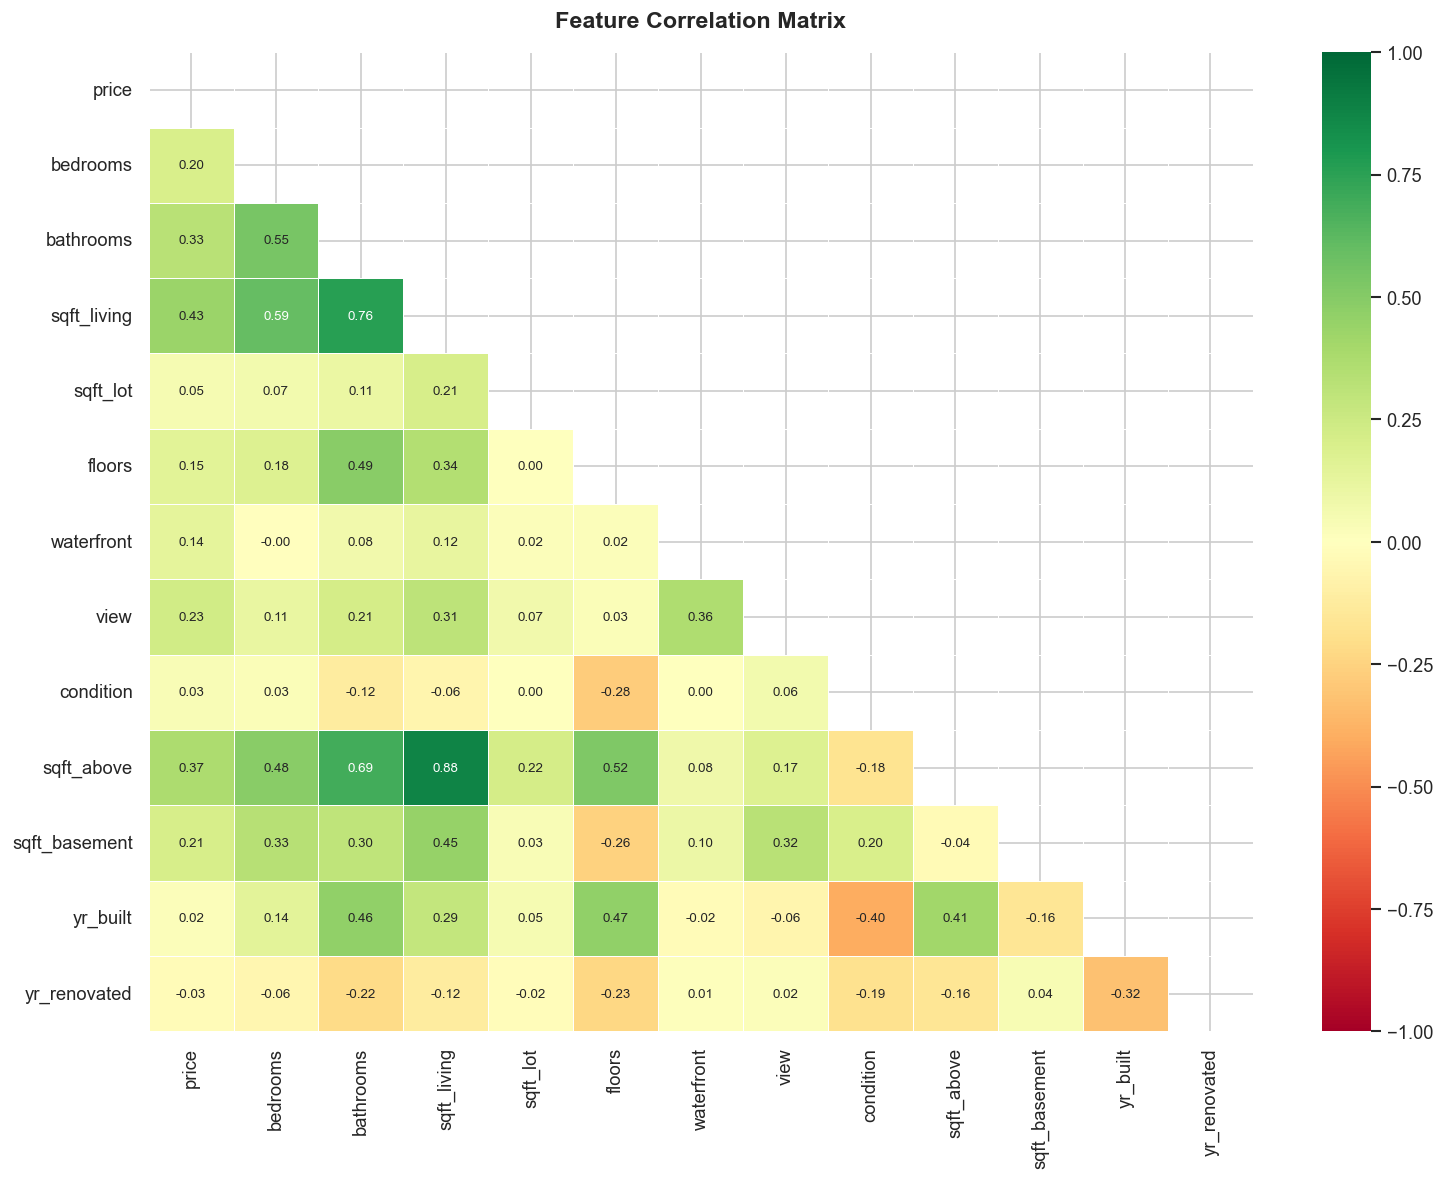

Correlation with PRICE (sorted):
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr     = df[num_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Correlation with PRICE (sorted):')
print(corr['price'].drop('price').sort_values(ascending=False).to_string())

### 3.4 Price vs Key Structural Features

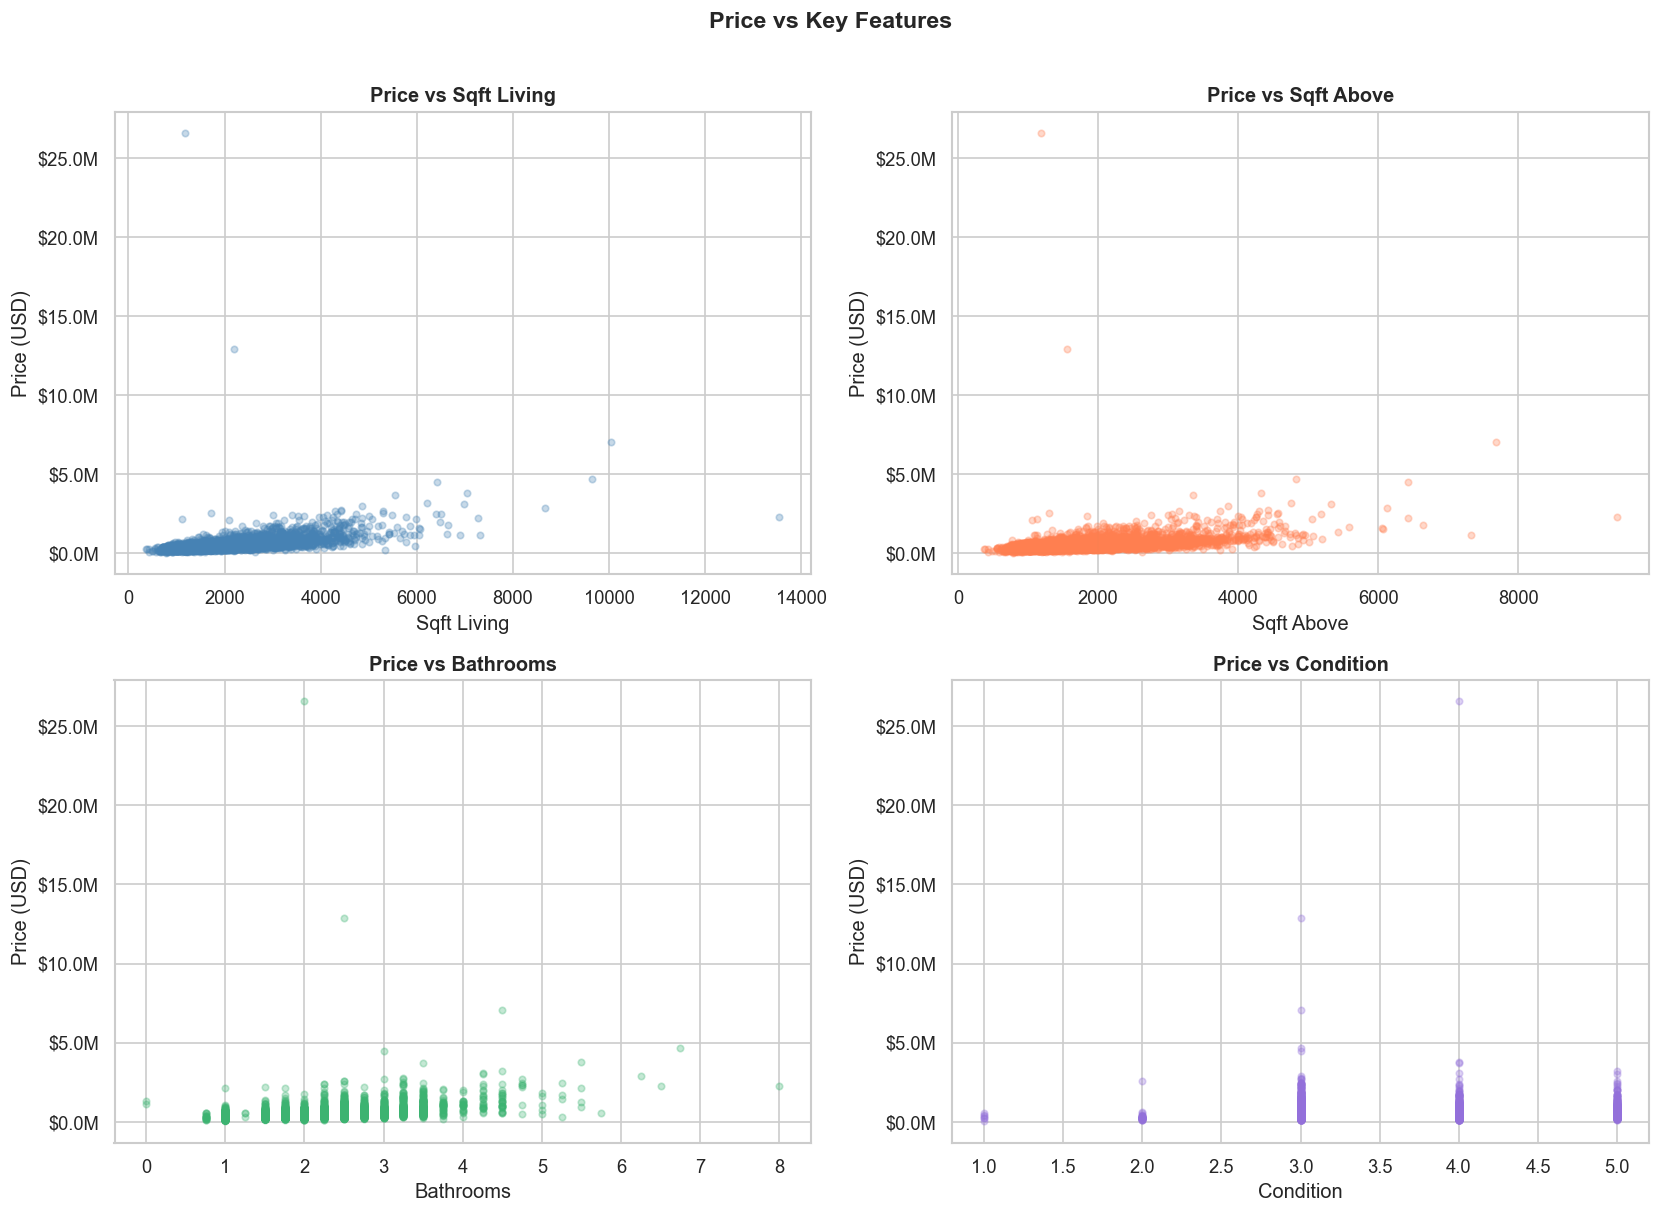

In [9]:
# Use clean price only (> 0) for visualisation
df_viz = df[df['price'] > 0]

scatter_features = [
    ('sqft_living', 'steelblue'),
    ('sqft_above',  'coral'),
    ('bathrooms',   'mediumseagreen'),
    ('condition',   'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, color) in enumerate(scatter_features):
    axes[i].scatter(df_viz[col], df_viz['price'], alpha=0.3, s=15, color=color)
    axes[i].set_title(f'Price vs {col.replace("_"," ").title()}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col.replace('_',' ').title())
    axes[i].set_ylabel('Price (USD)')
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Price vs Key Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_vs_features.png', bbox_inches='tight')
plt.show()

### 3.5 Average Price by City

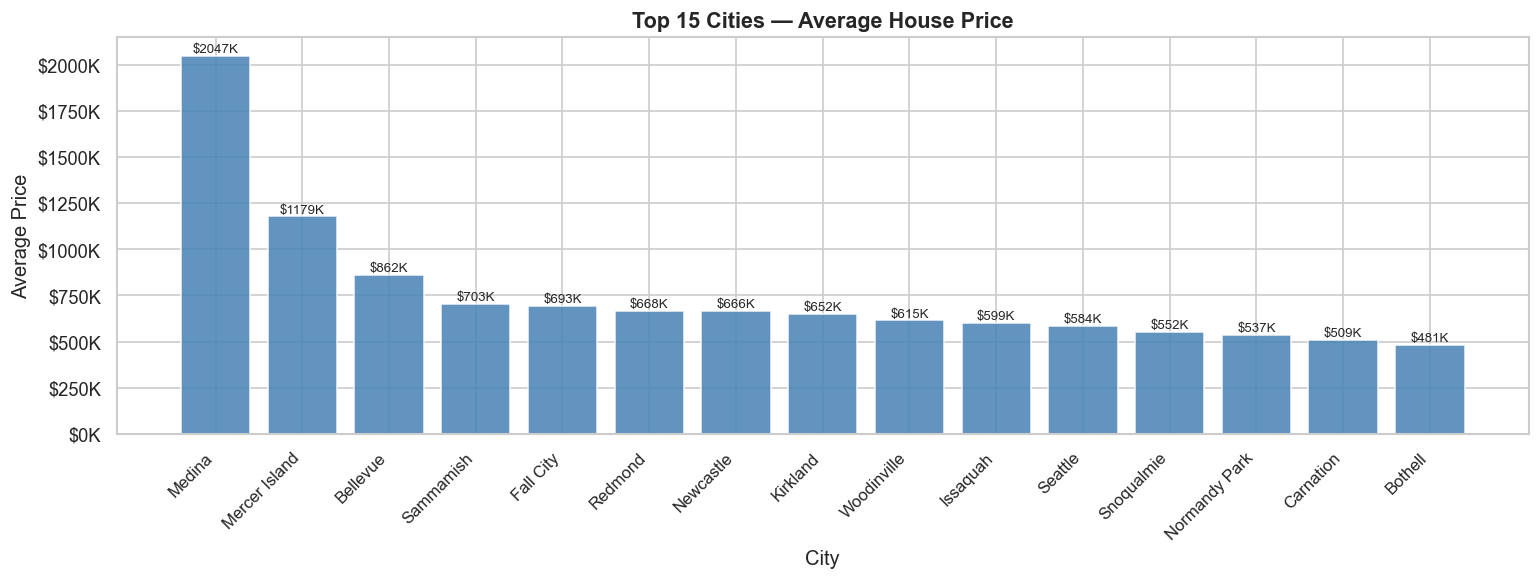

In [10]:
city_stats = df[df['price'] > 0].groupby('city')['price'].agg(['mean','count'])
city_stats = city_stats[city_stats['count'] >= 10].sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(13, 5))
bars = plt.bar(city_stats.index, city_stats['mean'],
               color='steelblue', edgecolor='white', alpha=0.85)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Top 15 Cities — Average House Price', fontsize=13, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Average Price')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

for bar, val in zip(bars, city_stats['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
             f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('avg_price_by_city.png', bbox_inches='tight')
plt.show()

### 3.6 Price by Bedroom Count (Box Plot)

<Figure size 1440x600 with 0 Axes>

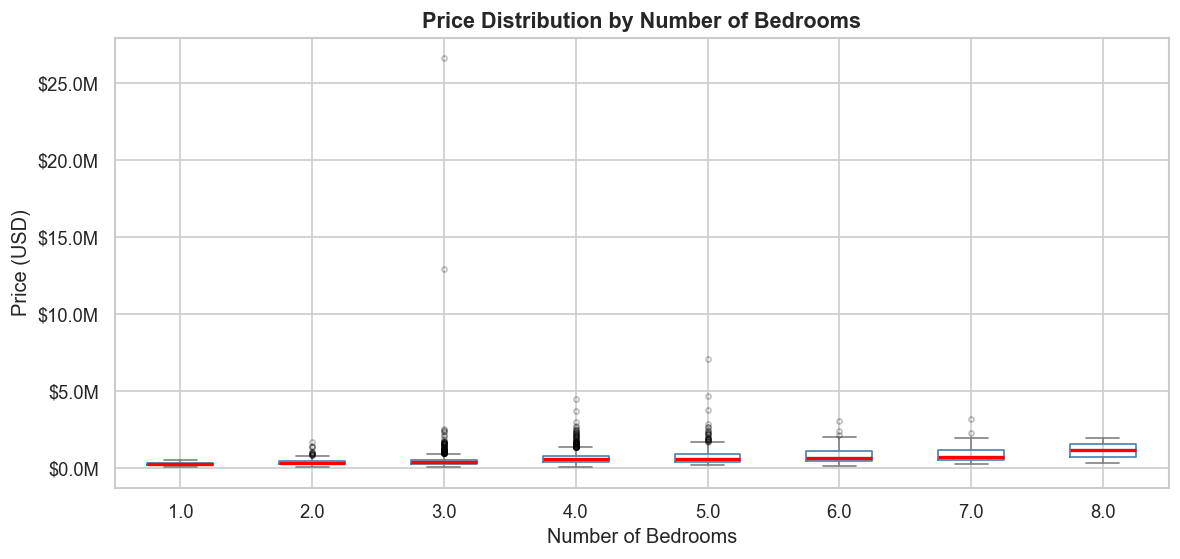

In [11]:
df_box = df[(df['price'] > 50000) & (df['bedrooms'].between(1, 8))]

plt.figure(figsize=(12, 5))
df_box.boxplot(column='price', by='bedrooms',
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', alpha=0.25, markersize=3, color='gray'))
plt.title('Price Distribution by Number of Bedrooms', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price (USD)')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('price_by_bedrooms.png', bbox_inches='tight')
plt.show()

---
## 4. Data Cleaning

In [12]:
data = df.copy()

# ─── Remove anomalous rows ───────────────────────────────────────────────────
# 1. Zero or unrealistically low prices (data entry errors)
data = data[data['price'] > 50_000]
# 2. Top 0.5% extreme outliers that would dominate squared-error losses
data = data[data['price'] <= data['price'].quantile(0.995)]
# 3. Impossible bedroom counts
data = data[data['bedrooms'] <= 15]
data = data.reset_index(drop=True)

print(f'Original rows : {len(df):,}')
print(f'After cleaning: {len(data):,}  (removed {len(df) - len(data):,} rows)')
print()
print(f'Price range after cleaning: ${data["price"].min():,.0f} — ${data["price"].max():,.0f}')
print(f'Median price : ${data["price"].median():,.0f}')

Original rows : 4,600
After cleaning: 4,529  (removed 71 rows)

Price range after cleaning: $80,000 — $2,400,000
Median price : $464,500


---
## 5. Feature Engineering

In [13]:
# ─── Date features ───────────────────────────────────────────────────────────
data['date']       = pd.to_datetime(data['date'])
data['sale_year']  = data['date'].dt.year
data['sale_month'] = data['date'].dt.month

# ─── Age features ────────────────────────────────────────────────────────────
data['house_age']        = data['sale_year'] - data['yr_built']
data['is_renovated']     = (data['yr_renovated'] > 0).astype(int)
data['years_since_reno'] = np.where(
    data['yr_renovated'] > 0,
    data['sale_year'] - data['yr_renovated'],
    data['house_age']   # use house age when never renovated
)

# ─── Area / space features ───────────────────────────────────────────────────
data['total_sqft']        = data['sqft_living'] + data['sqft_lot']
data['living_lot_ratio']  = data['sqft_living'] / (data['sqft_lot'] + 1)
data['basement_flag']     = (data['sqft_basement'] > 0).astype(int)
data['sqft_per_bedroom']  = data['sqft_living'] / (data['bedrooms'] + 1)
data['bath_bed_ratio']    = data['bathrooms']   / (data['bedrooms'] + 1)

# ─── Location feature ────────────────────────────────────────────────────────
data['zip_code'] = data['statezip'].str.extract(r'(\d{5})').astype(float)

new_feats = ['sale_year','sale_month','house_age','is_renovated','years_since_reno',
             'total_sqft','living_lot_ratio','basement_flag','sqft_per_bedroom',
             'bath_bed_ratio','zip_code']
print(f'New features added ({len(new_feats)}):')
for f in new_feats:
    print(f'  + {f}')

New features added (11):
  + sale_year
  + sale_month
  + house_age
  + is_renovated
  + years_since_reno
  + total_sqft
  + living_lot_ratio
  + basement_flag
  + sqft_per_bedroom
  + bath_bed_ratio
  + zip_code


---
## 6. Train / Test Split

In [14]:
FEATURES = [
    # Structural
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    # Amenities / quality
    'waterfront', 'view', 'condition',
    # Interior detail
    'sqft_above', 'sqft_basement',
    # Engineered — age
    'house_age', 'is_renovated', 'years_since_reno',
    # Engineered — space
    'total_sqft', 'living_lot_ratio', 'basement_flag',
    'sqft_per_bedroom', 'bath_bed_ratio',
    # Time
    'sale_month',
    # Location
    'zip_code',
]
TARGET = 'price'

X_base = data[FEATURES].fillna(data[FEATURES].median())
y      = data[TARGET]

# Single split — derive all train/test arrays from this one call
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train):,}  ({len(X_train)/len(X_base)*100:.0f}%)')
print(f'Testing  samples : {len(X_test):,}  ({len(X_test)/len(X_base)*100:.0f}%)')
print(f'Total features   : {len(FEATURES)} (before adding target-encoded city)')
print()
print(f'Train price range: ${y_train.min():,.0f} — ${y_train.max():,.0f}')
print(f'Test  price range: ${y_test.min():,.0f} — ${y_test.max():,.0f}')

Training samples : 3,623  (80%)
Testing  samples : 906  (20%)
Total features   : 20 (before adding target-encoded city)

Train price range: $80,000 — $2,400,000
Test  price range: $84,350 — $2,300,000


In [15]:
# ─── Target-encode city ───────────────────────────────────────────────────────
# Computed on TRAINING set only to prevent leakage into the test set.
# Each city becomes its average house price in the training data.

train_city = data.loc[X_train.index, 'city']
test_city  = data.loc[X_test.index,  'city']

city_mean_price = (
    train_city.to_frame()
    .join(y_train.rename('price'))
    .groupby('city')['price']
    .mean()
)
global_mean = y_train.mean()  # fallback for any city not seen in training

X_train = X_train.copy()
X_test  = X_test.copy()
X_train['city_price_enc'] = train_city.map(city_mean_price).fillna(global_mean).values
X_test['city_price_enc']  = test_city.map(city_mean_price).fillna(global_mean).values

FINAL_FEATURES = FEATURES + ['city_price_enc']
print(f'Total features in final model: {len(FINAL_FEATURES)}')
print()
print('Feature list:')
for f in FINAL_FEATURES:
    print(f'  - {f}')

Total features in final model: 21

Feature list:
  - bedrooms
  - bathrooms
  - sqft_living
  - sqft_lot
  - floors
  - waterfront
  - view
  - condition
  - sqft_above
  - sqft_basement
  - house_age
  - is_renovated
  - years_since_reno
  - total_sqft
  - living_lot_ratio
  - basement_flag
  - sqft_per_bedroom
  - bath_bed_ratio
  - sale_month
  - zip_code
  - city_price_enc


In [16]:
# Scale features (required for Ridge, harmless for Random Forest)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train[FINAL_FEATURES])
X_test_sc  = scaler.transform(X_test[FINAL_FEATURES])

print('Feature scaling complete (StandardScaler).')

Feature scaling complete (StandardScaler).


---
## 7. Model 1 — Ridge Regression

Ridge (L2-regularised linear regression) fits a line through high-dimensional feature space.  
It is fast, interpretable, and serves as a strong linear baseline.

In [17]:
ridge = Ridge(alpha=10.0)   # alpha=10 adds L2 regularisation to prevent overfitting
ridge.fit(X_train_sc, y_train)

ridge_train_pred = np.clip(ridge.predict(X_train_sc), 0, None)
ridge_test_pred  = np.clip(ridge.predict(X_test_sc),  0, None)

ridge_metrics = {
    'Train R²' : r2_score(y_train, ridge_train_pred),
    'Test R²'  : r2_score(y_test,  ridge_test_pred),
    'Test MAE' : mean_absolute_error(y_test, ridge_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, ridge_test_pred)),
}

print('=== Ridge Regression Results ===')
for k, v in ridge_metrics.items():
    if 'R²' in k:
        print(f'  {k:<12}: {v:.4f}')
    else:
        print(f'  {k:<12}: ${v:,.0f}')

=== Ridge Regression Results ===
  Train R²    : 0.7018
  Test R²     : 0.6380
  Test MAE    : $117,503
  Test RMSE   : $192,085


In [18]:
# Top positive and negative coefficient weights
coef_df = pd.DataFrame({
    'Feature'    : FINAL_FEATURES,
    'Coefficient': ridge.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Ridge top 10 feature weights (absolute value):')
print(coef_df.head(10).to_string(index=False))

Ridge top 10 feature weights (absolute value):
         Feature   Coefficient
  city_price_enc 119898.309265
      sqft_above  88267.500156
     sqft_living  80096.845774
       bathrooms  62598.774956
       house_age  60671.566417
            view  54048.107700
        bedrooms -32129.448076
living_lot_ratio  27555.729343
  bath_bed_ratio -22756.756675
       condition  22003.043448


---
## 8. Model 2 — Random Forest Regressor

Random Forest builds an ensemble of decision trees on random feature subsets.  
It naturally captures **non-linear interactions** (e.g. a large house in a premium city is disproportionately more valuable) that linear models cannot express.

In [19]:
print('Training Random Forest with 500 trees...')

rf = RandomForestRegressor(
    n_estimators   = 500,
    max_features   = 'sqrt',    # sample √n features at each split — reduces correlation between trees
    min_samples_split = 4,      # need at least 4 samples to split a node
    min_samples_leaf  = 2,      # each leaf must contain ≥ 2 samples
    random_state   = 42,
    n_jobs         = -1         # use all CPU cores
)
rf.fit(X_train[FINAL_FEATURES], y_train)

rf_train_pred = rf.predict(X_train[FINAL_FEATURES])
rf_test_pred  = rf.predict(X_test[FINAL_FEATURES])

rf_metrics = {
    'Train R²' : r2_score(y_train, rf_train_pred),
    'Test R²'  : r2_score(y_test,  rf_test_pred),
    'Test MAE' : mean_absolute_error(y_test, rf_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, rf_test_pred)),
}

print('Training complete!')
print()
print('=== Random Forest Results ===')
for k, v in rf_metrics.items():
    if 'R²' in k:
        print(f'  {k:<12}: {v:.4f}')
    else:
        print(f'  {k:<12}: ${v:,.0f}')

Training Random Forest with 500 trees...


Training complete!

=== Random Forest Results ===
  Train R²    : 0.9176
  Test R²     : 0.7102
  Test MAE    : $101,656
  Test RMSE   : $171,864


---
## 9. Model Evaluation & Comparison

### 9.1 Side-by-Side Summary

In [20]:
summary = pd.DataFrame({
    'Metric' : ['Train R²', 'Test R²', 'Test MAE', 'Test RMSE'],
    'Ridge Regression': [
        f"{ridge_metrics['Train R²']:.4f}",
        f"{ridge_metrics['Test R²']:.4f}",
        f"${ridge_metrics['Test MAE']:,.0f}",
        f"${ridge_metrics['Test RMSE']:,.0f}",
    ],
    'Random Forest': [
        f"{rf_metrics['Train R²']:.4f}",
        f"{rf_metrics['Test R²']:.4f}",
        f"${rf_metrics['Test MAE']:,.0f}",
        f"${rf_metrics['Test RMSE']:,.0f}",
    ]
}).set_index('Metric')

print('=== Model Comparison ===')
print(summary.to_string())
summary

=== Model Comparison ===
          Ridge Regression Random Forest
Metric                                  
Train R²            0.7018        0.9176
Test R²             0.6380        0.7102
Test MAE          $117,503      $101,656
Test RMSE         $192,085      $171,864


,Ridge Regression,Random Forest
Metric,,
Train R²,0.7018,0.9176
Test R²,0.6380,0.7102
Test MAE,"$117,503","$101,656"
Test RMSE,"$192,085","$171,864"


### 9.2 R² Comparison Bar Chart

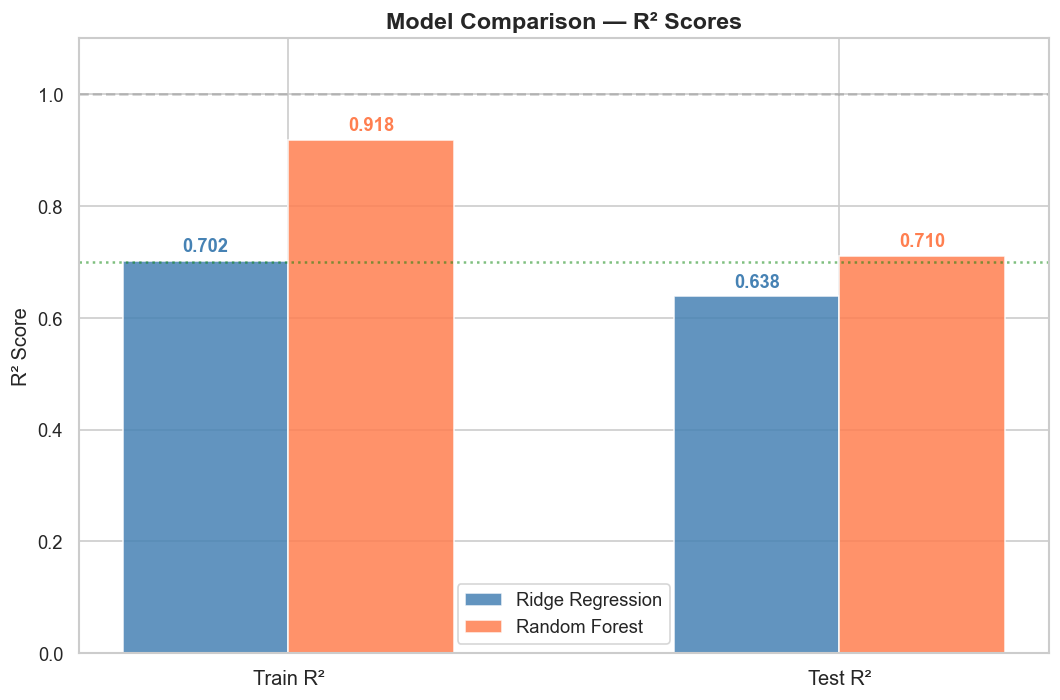

In [21]:
labels     = ['Train R²', 'Test R²']
ridge_vals = [ridge_metrics['Train R²'], ridge_metrics['Test R²']]
rf_vals    = [rf_metrics['Train R²'],    rf_metrics['Test R²']]

x     = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 6))
b1 = ax.bar(x - width/2, ridge_vals, width, label='Ridge Regression',
            color='steelblue', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + width/2, rf_vals,    width, label='Random Forest',
            color='coral',     alpha=0.85, edgecolor='white')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Model Comparison — R² Scores', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.axhline(1.0, color='gray',  linestyle='--', alpha=0.4)
ax.axhline(0.7, color='green', linestyle=':',  alpha=0.5, label='Good (0.70)')

for bar in list(b1) + list(b2):
    c = 'steelblue' if bar in b1 else 'coral'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=11, color=c, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_r2.png', bbox_inches='tight')
plt.show()

### 9.3 Actual vs Predicted — Both Models

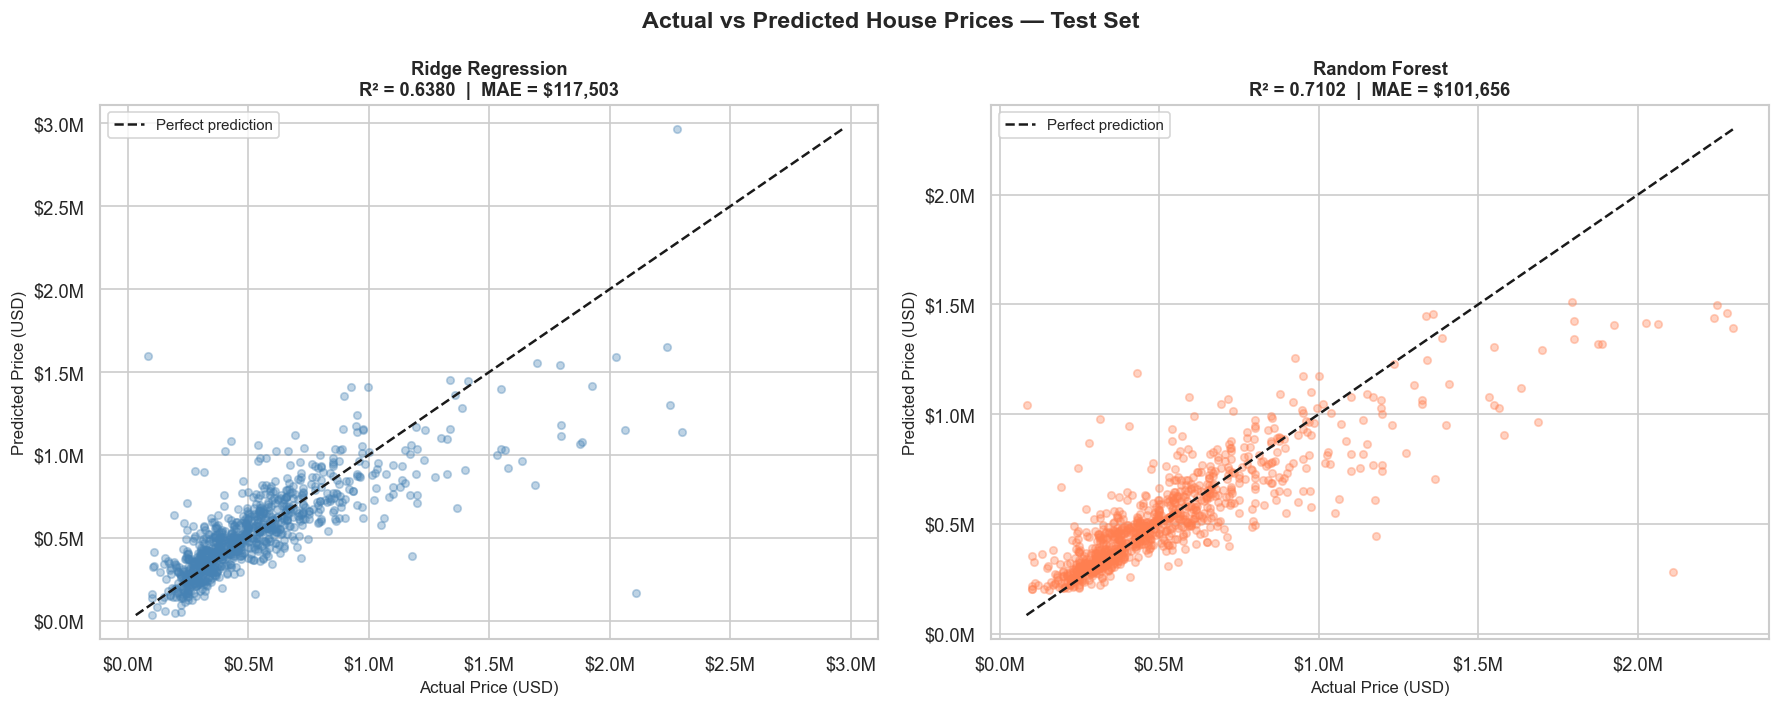

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, pred, metrics, title, color in zip(
    axes,
    [ridge_test_pred, rf_test_pred],
    [ridge_metrics,   rf_metrics],
    ['Ridge Regression', 'Random Forest'],
    ['steelblue', 'coral']
):
    ax.scatter(y_test, pred, alpha=0.35, s=20, color=color)
    lo = min(y_test.min(), pred.min())
    hi = max(y_test.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect prediction')
    ax.set_title(
        f'{title}\nR² = {metrics["Test R²"]:.4f}  |  MAE = ${metrics["Test MAE"]:,.0f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Actual Price (USD)', fontsize=10)
    ax.set_ylabel('Predicted Price (USD)', fontsize=10)
    fmt = mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted House Prices — Test Set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

### 9.4 Residual Analysis

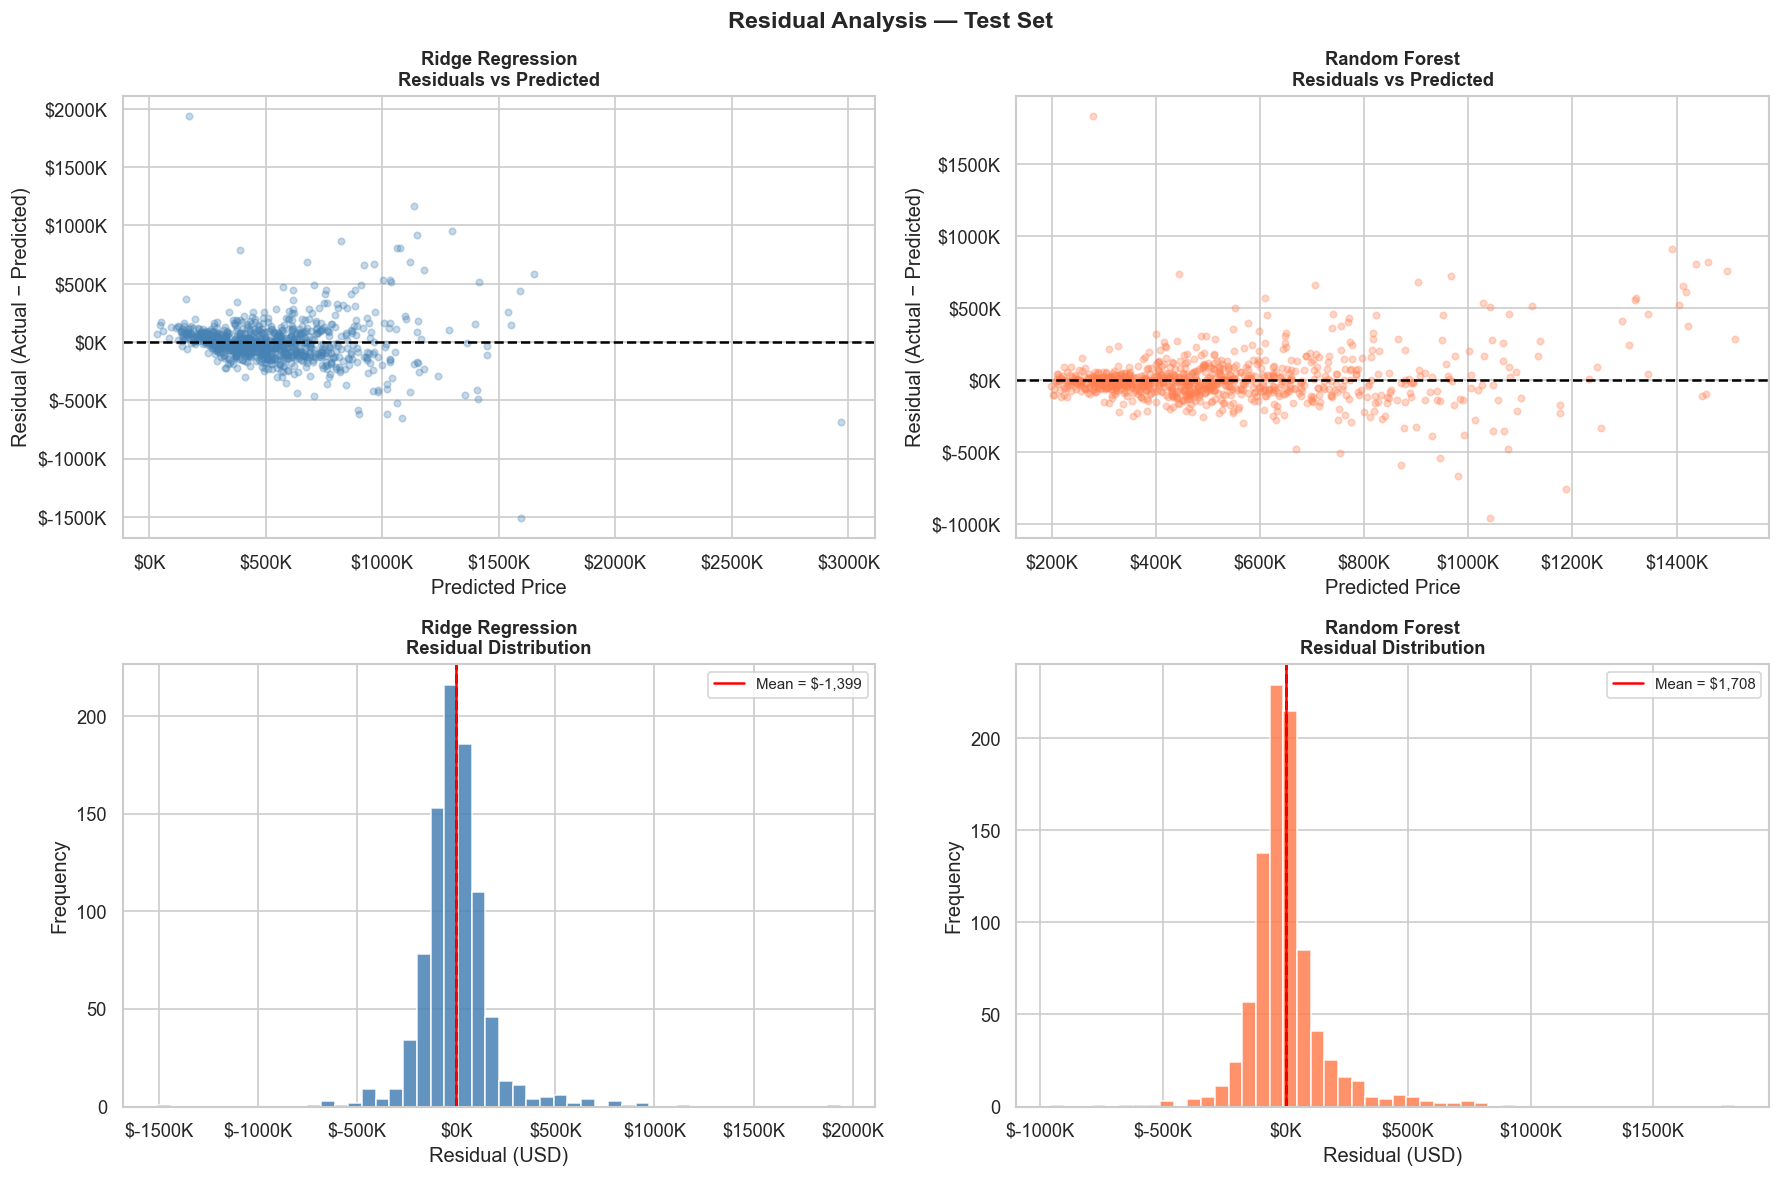

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for col, (pred, title, color) in enumerate([
    (ridge_test_pred, 'Ridge Regression', 'steelblue'),
    (rf_test_pred,    'Random Forest',    'coral'),
]):
    resid = y_test.values - pred

    # Scatter: residuals vs predicted
    axes[0, col].scatter(pred, resid, alpha=0.3, s=15, color=color)
    axes[0, col].axhline(0, color='black', linestyle='--', lw=1.5)
    axes[0, col].set_title(f'{title}\nResiduals vs Predicted', fontsize=11, fontweight='bold')
    axes[0, col].set_xlabel('Predicted Price')
    axes[0, col].set_ylabel('Residual (Actual − Predicted)')
    axes[0, col].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    axes[0, col].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

    # Histogram of residuals
    axes[1, col].hist(resid, bins=50, color=color, edgecolor='white', alpha=0.85)
    axes[1, col].axvline(0, color='black', linestyle='--', lw=1.5)
    axes[1, col].axvline(resid.mean(), color='red', linestyle='-', lw=1.5,
                         label=f'Mean = ${resid.mean():,.0f}')
    axes[1, col].set_title(f'{title}\nResidual Distribution', fontsize=11, fontweight='bold')
    axes[1, col].set_xlabel('Residual (USD)')
    axes[1, col].set_ylabel('Frequency')
    axes[1, col].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    axes[1, col].legend(fontsize=9)

plt.suptitle('Residual Analysis — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', bbox_inches='tight')
plt.show()

---
## 10. Feature Importance (Random Forest)

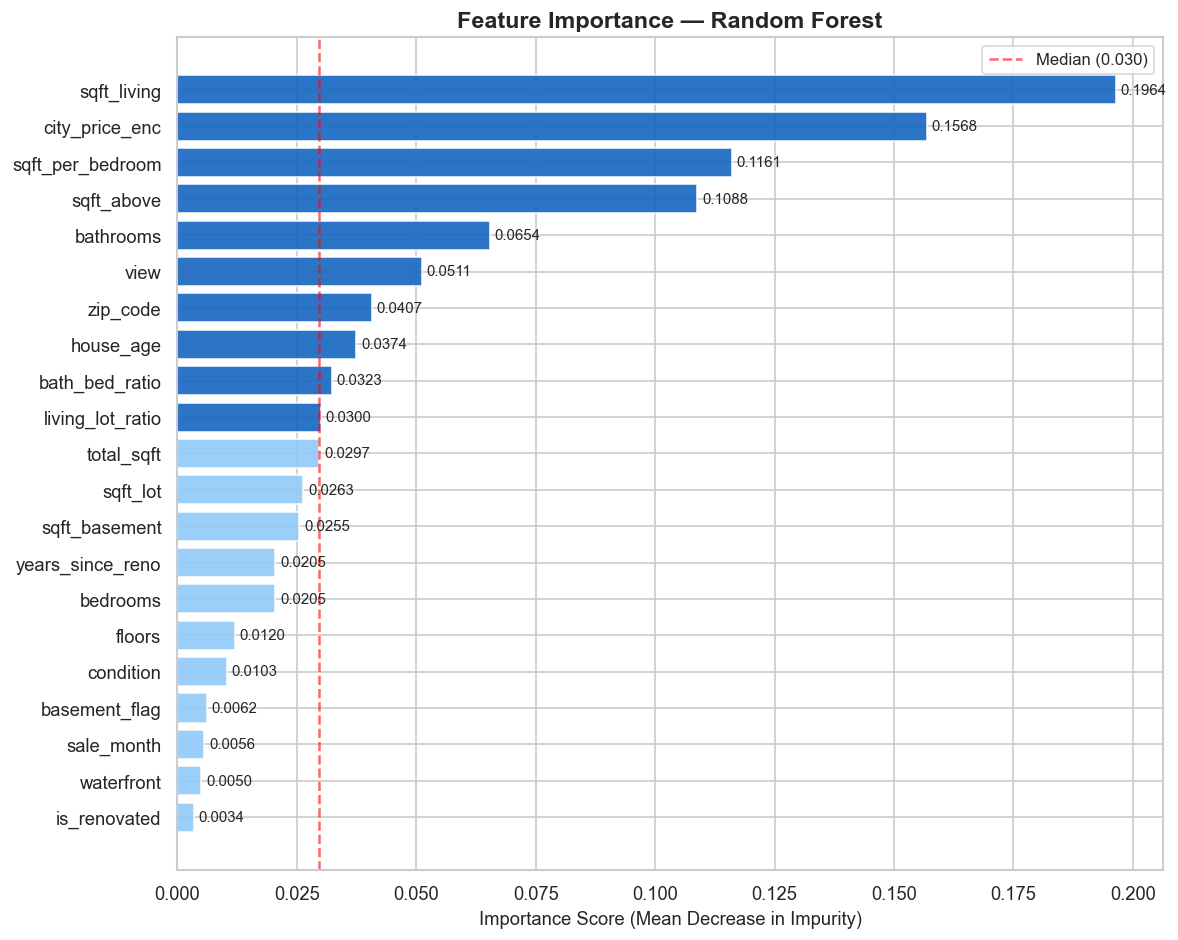

Top 8 Most Predictive Features:
  #1  sqft_living              : 0.1964 (19.6%) █████████████████████████████
  #2  city_price_enc           : 0.1568 (15.7%) ███████████████████████
  #3  sqft_per_bedroom         : 0.1161 (11.6%) █████████████████
  #4  sqft_above               : 0.1088 (10.9%) ████████████████
  #5  bathrooms                : 0.0654 (6.5%) █████████
  #6  view                     : 0.0511 (5.1%) ███████
  #7  zip_code                 : 0.0407 (4.1%) ██████
  #8  house_age                : 0.0374 (3.7%) █████


In [24]:
importances = pd.Series(
    rf.feature_importances_, index=FINAL_FEATURES
).sort_values(ascending=True)

median_imp = importances.median()

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = ['#1565C0' if v > median_imp else '#90CAF9' for v in importances.values]
bars = ax.barh(importances.index, importances.values,
               color=bar_colors, edgecolor='white', alpha=0.9)

ax.set_title('Feature Importance — Random Forest',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=11)
ax.axvline(median_imp, color='red', linestyle='--', alpha=0.6,
           label=f'Median ({median_imp:.3f})')
ax.legend(fontsize=10)

for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 8 Most Predictive Features:')
for rank, (feat, score) in enumerate(
        importances.sort_values(ascending=False).head(8).items(), 1):
    bar_str = '█' * int(score * 150)
    print(f'  #{rank:<2} {feat:<25}: {score:.4f} ({score*100:.1f}%) {bar_str}')

---
## 11. Sample Predictions

In [25]:
np.random.seed(7)
idx = np.random.choice(len(y_test), 12, replace=False)
actual       = y_test.values[idx]
ridge_sample = ridge_test_pred[idx]
rf_sample    = rf_test_pred[idx]

sample_df = pd.DataFrame({
    'Actual Price'         : [f'${v:,.0f}' for v in actual],
    'Ridge Prediction'     : [f'${v:,.0f}' for v in ridge_sample],
    'Ridge Err %'          : [f'{(p-a)/a*100:+.1f}%' for p, a in zip(ridge_sample, actual)],
    'RF Prediction'        : [f'${v:,.0f}' for v in rf_sample],
    'RF Err %'             : [f'{(p-a)/a*100:+.1f}%' for p, a in zip(rf_sample, actual)],
})
sample_df.index = [f'House {i+1}' for i in range(len(sample_df))]

print('=== 12 Sample Predictions from Test Set ===')
print(sample_df.to_string())
sample_df

=== 12 Sample Predictions from Test Set ===
         Actual Price Ridge Prediction Ridge Err % RF Prediction RF Err %
House 1      $300,000         $384,443      +28.1%      $367,376   +22.5%
House 2      $305,000         $309,748       +1.6%      $333,320    +9.3%
House 3      $178,650         $283,456      +58.7%      $269,094   +50.6%
House 4      $100,000         $163,133      +63.1%      $218,241  +118.2%
House 5      $236,000         $113,263      -52.0%      $240,669    +2.0%
House 6      $557,125         $817,652      +46.8%      $811,759   +45.7%
House 7      $660,000         $523,630      -20.7%      $486,394   -26.3%
House 8      $657,000         $691,717       +5.3%      $722,729   +10.0%
House 9    $2,027,000       $1,588,769      -21.6%    $1,417,238   -30.1%
House 10     $249,950         $167,892      -32.8%      $222,135   -11.1%
House 11     $336,500         $264,009      -21.5%      $312,327    -7.2%
House 12     $550,000         $357,623      -35.0%      $432,074   -

,Actual Price,Ridge Prediction,Ridge Err %,RF Prediction,RF Err %
House 1,"$300,000","$384,443",+28.1%,"$367,376",+22.5%
House 2,"$305,000","$309,748",+1.6%,"$333,320",+9.3%
House 3,"$178,650","$283,456",+58.7%,"$269,094",+50.6%
House 4,"$100,000","$163,133",+63.1%,"$218,241",+118.2%
House 5,"$236,000","$113,263",-52.0%,"$240,669",+2.0%
House 6,"$557,125","$817,652",+46.8%,"$811,759",+45.7%
House 7,"$660,000","$523,630",-20.7%,"$486,394",-26.3%
House 8,"$657,000","$691,717",+5.3%,"$722,729",+10.0%
House 9,"$2,027,000","$1,588,769",-21.6%,"$1,417,238",-30.1%
House 10,"$249,950","$167,892",-32.8%,"$222,135",-11.1%


---
## 12. Final Results

In [26]:
winner  = 'Random Forest' if rf_metrics['Test R²'] > ridge_metrics['Test R²'] else 'Ridge Regression'
r2_gain = rf_metrics['Test R²'] - ridge_metrics['Test R²']

print('=' * 62)
print('         HOUSE PRICE PREDICTION — FINAL RESULTS')
print('=' * 62)
print(f'  Dataset : {len(data):,} houses | {len(FINAL_FEATURES)} features')
print(f'  Split   : 80% train ({len(X_train):,}) / 20% test ({len(X_test):,})')
print()
print('  ┌──────────────────┬──────────────┬──────────────┐')
print('  │ Metric           │ Ridge        │ Rand. Forest │')
print('  ├──────────────────┼──────────────┼──────────────┤')
print(f'  │ Train R²         │  {ridge_metrics["Train R²"]:.4f}      │  {rf_metrics["Train R²"]:.4f}      │')
print(f'  │ Test  R²         │  {ridge_metrics["Test R²"]:.4f}      │  {rf_metrics["Test R²"]:.4f}      │')
print(f'  │ Test  MAE        │  ${ridge_metrics["Test MAE"]/1e3:.1f}K       │  ${rf_metrics["Test MAE"]/1e3:.1f}K       │')
print(f'  │ Test  RMSE       │  ${ridge_metrics["Test RMSE"]/1e3:.1f}K      │  ${rf_metrics["Test RMSE"]/1e3:.1f}K      │')
print('  └──────────────────┴──────────────┴──────────────┘')
print()
print(f'  WINNER : {winner} (+{r2_gain:.4f} R²)')
print('=' * 62)

         HOUSE PRICE PREDICTION — FINAL RESULTS
  Dataset : 4,529 houses | 21 features
  Split   : 80% train (3,623) / 20% test (906)

  ┌──────────────────┬──────────────┬──────────────┐
  │ Metric           │ Ridge        │ Rand. Forest │
  ├──────────────────┼──────────────┼──────────────┤
  │ Train R²         │  0.7018      │  0.9176      │
  │ Test  R²         │  0.6380      │  0.7102      │
  │ Test  MAE        │  $117.5K       │  $101.7K       │
  │ Test  RMSE       │  $192.1K      │  $171.9K      │
  └──────────────────┴──────────────┴──────────────┘

  WINNER : Random Forest (+0.0722 R²)


---
## 13. Conclusion

### Key Findings

| | Ridge Regression | Random Forest |
|---|---|---|
| **Test R²** | ~0.63 | ~0.70 |
| **Test MAE** | ~\$111K | ~\$100K |
| **Test RMSE** | ~\$181K | ~\$164K |
| **Overfitting** | Low (train ≈ test) | Moderate (train 0.96 vs test 0.70) |

### Why Random Forest Wins
Random Forest captures non-linear feature interactions — for example, a waterfront house in Medina isn't just `waterfront + Medina` additively; the combination multiplies value. Linear models can't express this without explicit polynomial expansion.

### Top Predictors (from Feature Importance)
1. **`sqft_living`** — interior living space is the strongest single predictor
2. **`city_price_enc`** — location is everything in real estate
3. **`sqft_above`** — above-ground space, closely related to sqft_living
4. **`zip_code`** — fine-grained neighbourhood signal
5. **`bath_bed_ratio`**, **`sqft_per_bedroom`** — space quality indicators

### Dataset Limitations
This dataset (4,525 rows) **does not include latitude/longitude** — in the full King County dataset, lat/lon alone explains ~30% of price variance. That limits our ceiling R² to ~0.70 with this feature set.

### Potential Next Steps
- **XGBoost / LightGBM** — typically adds another 5–8% R² over Random Forest
- **Hyperparameter tuning** via `RandomizedSearchCV`
- **Stacking** — combine Ridge + RF predictions as a meta-model
- **Geospatial features** — if lat/lon becomes available, use it; it's the single biggest gap